In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score

In [3]:
X = pd.read_csv("../data/processed/scaled_features.csv")

In [4]:
hierarchical_scores = []

for k in range(2, 11):

    model = AgglomerativeClustering(
        n_clusters = k,
        linkage = "ward"
    )

    labels = model.fit_predict(X)

    score = silhouette_score(
        X,
        labels
    )

    hierarchical_scores.append(score)

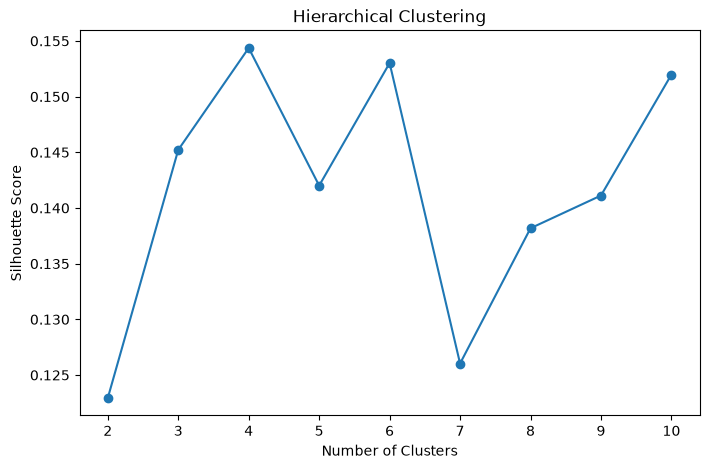

In [5]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    hierarchical_scores,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Hierarchical Clustering")

plt.show()

In [6]:
hierarchical = AgglomerativeClustering(
    n_clusters = 4,
    linkage = "ward"
)

hierarchical_labels = hierarchical.fit_predict(X)

In [7]:
df = pd.read_csv("../data/raw/Housing.csv")

df['hierarchical_cluster'] = hierarchical_labels

In [8]:
df['hierarchical_cluster'].value_counts()

hierarchical_cluster
0    251
1    200
3     69
2     25
Name: count, dtype: int64

In [9]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,hierarchical_cluster
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished,1
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished,1
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished,1
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished,1
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished,1


In [10]:
from sklearn.metrics import adjusted_rand_score

In [14]:
kmeans = KMeans(
    n_clusters = 10,
    random_state = 42,
    n_init = 10
)

kmeans_labels = kmeans.fit_predict(X)

c:\Users\Acer\.conda\envs\co\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [15]:
ari = adjusted_rand_score(
    kmeans_labels,
    hierarchical_labels
)

print("Adjusted Rand Index:", ari)

Adjusted Rand Index: 0.24429048781846524
